In [1]:
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving 44833-lighthouse-168132_1920.jpg to 44833-lighthouse-168132_1920.jpg


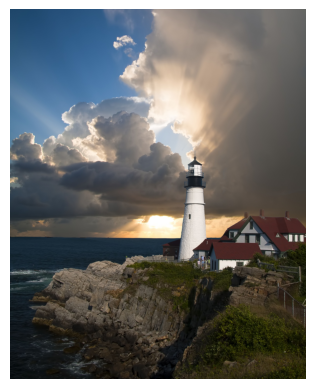

In [4]:
image = Image.open(list(uploaded.keys())[0])

plt.imshow(image)
plt.axis("off")
plt.show()

In [13]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git


Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 30.56 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [14]:
%cd pytorch-CycleGAN-and-pix2pix

/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix


In [15]:
!pip install dominate visdom -q

In [16]:
!bash ./scripts/download_cyclegan_model.sh style_monet

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-03 16:17:48--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  29.1MB/s    in 1.5s    

2026-10-03 16:17:49 (29.1 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [19]:
import os

os.makedirs("../my_image/testA", exist_ok=True)

filename = list(uploaded.keys())[0]

with open("../my_image/testA/" + filename, "wb") as f:
    f.write(uploaded[filename])

print("Image copied successfully!")

Image copied successfully!


In [20]:
!python test.py --dataroot ../my_image --name style_monet_pretrained --model test --no_dropout

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ../my_image                   	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

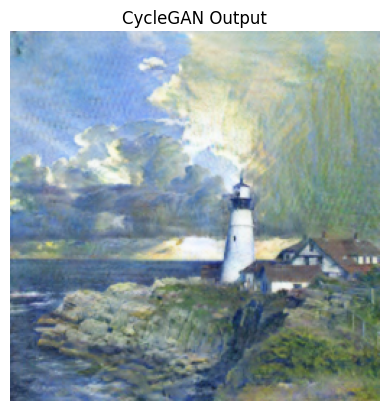

In [21]:
import glob

result_file = glob.glob(
    "results/style_monet_pretrained/test_latest/images/*fake*.png"
)[0]

cyclegan_output = Image.open(result_file)

plt.imshow(cyclegan_output)
plt.title("CycleGAN Output")
plt.axis("off")
plt.show()

In [23]:
from google.colab import files

style_uploaded = files.upload()

Saving 44833-lighthouse-168132_1920.jpg to 44833-lighthouse-168132_1920.jpg


In [24]:
import io

style_image = Image.open(
    io.BytesIO(list(style_uploaded.values())[0])
).convert("RGB")

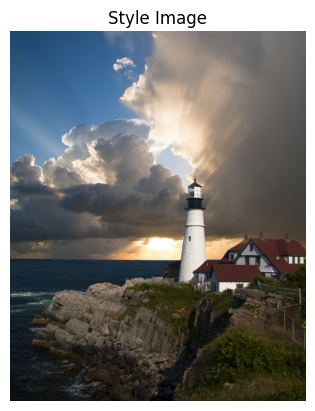

In [25]:
plt.imshow(style_image)
plt.title("Style Image")
plt.axis("off")
plt.show()

In [26]:
from torchvision.models import vgg19, VGG19_Weights

vgg = vgg19(weights=VGG19_Weights.DEFAULT).features
vgg.eval()

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:09<00:00, 62.1MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [47]:

from PIL import Image
import requests

url = "https://raw.githubusercontent.com/NielsNL4/Van-Gogh-Converter/master/starrynight.jpg"

response = requests.get(url)
open("starrynight.jpg", "wb").write(response.content)

style_image = Image.open("starrynight.jpg").convert("RGB")
style_image = style_image.resize((256, 256))

print("Starry Night loaded successfully!")

Starry Night loaded successfully!


In [48]:
content_tensor = transform(content_image).unsqueeze(0)
style_tensor = transform(style_image).unsqueeze(0)

In [49]:
from torchvision import transforms

transform = transforms.ToTensor()

content_tensor = transform(content_image).unsqueeze(0)
style_tensor = transform(style_image).unsqueeze(0)

print("Images converted successfully!")

Images converted successfully!


Using device: cpu
Step: 0 Loss: 20.771055221557617
Step: 50 Loss: 2.3239309787750244
Step: 100 Loss: 2.0252904891967773
Step: 150 Loss: 1.9242362976074219
Step: 200 Loss: 1.8777639865875244
Step: 250 Loss: 1.8420865535736084


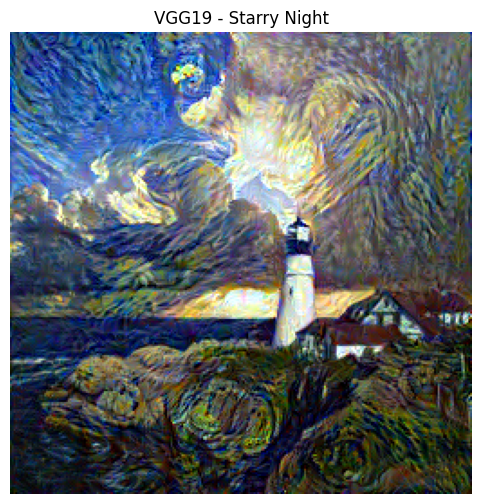

✅ Neural Style Transfer completed!


In [51]:
# ============================================
# NEURAL STYLE TRANSFER - VGG19 + STARry NIGHT
# ============================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models import vgg19, VGG19_Weights

# --------------------------------------------
# 1. Device
# --------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# --------------------------------------------
# 2. Load pretrained VGG19
# --------------------------------------------

vgg = vgg19(
    weights=VGG19_Weights.DEFAULT
).features.to(device).eval()

for p in vgg.parameters():
    p.requires_grad = False


# --------------------------------------------
# 3. Extract VGG features
# --------------------------------------------

def get_features(x):

    features = {}

    for name, layer in vgg._modules.items():

        x = layer(x)

        if name in ["0", "5", "10", "19", "21", "28"]:
            features[name] = x

    return features


# --------------------------------------------
# 4. Gram Matrix
# --------------------------------------------

def gram_matrix(x):

    b, c, h, w = x.size()

    x = x.view(b, c, h * w)

    return torch.bmm(
        x,
        x.transpose(1, 2)
    ) / (c * h * w)


# --------------------------------------------
# 5. Move images to device
# --------------------------------------------

content_tensor = content_tensor.to(device)
style_tensor = style_tensor.to(device)


# --------------------------------------------
# 6. Get content and style features
# --------------------------------------------

content_features = get_features(content_tensor)

style_features = get_features(style_tensor)


# --------------------------------------------
# 7. Calculate style Gram matrices
# --------------------------------------------

style_grams = {
    layer: gram_matrix(style_features[layer])
    for layer in style_features
}


# --------------------------------------------
# 8. Start target from original image
# --------------------------------------------

target = content_tensor.clone().detach()

target.requires_grad_(True)


# --------------------------------------------
# 9. Optimizer
# --------------------------------------------

optimizer = torch.optim.Adam(
    [target],
    lr=0.02
)


# --------------------------------------------
# 10. Style Transfer
# --------------------------------------------

for i in range(300):

    target_features = get_features(target)


    # Content loss
    content_loss = F.mse_loss(
        target_features["21"],
        content_features["21"]
    )


    # Style loss
    style_loss = 0

    for layer in ["0", "5", "10", "19", "28"]:

        target_gram = gram_matrix(
            target_features[layer]
        )

        style_loss += F.mse_loss(
            target_gram,
            style_grams[layer]
        )


    # Total loss
    loss = (
        content_loss
        + 1000000 * style_loss
    )


    # Update
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    # Keep pixel values between 0 and 1
    with torch.no_grad():
        target.clamp_(0, 1)


    # Print progress
    if i % 50 == 0:

        print(
            "Step:",
            i,
            "Loss:",
            loss.item()
        )


# --------------------------------------------
# 11. Convert output to image
# --------------------------------------------

output = target.detach().cpu().squeeze(0)

output = output.permute(
    1, 2, 0
).numpy()


# --------------------------------------------
# 12. Show NST output
# --------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(output)

plt.title(
    "VGG19 - Starry Night"
)

plt.axis("off")

plt.show()


print("✅ Neural Style Transfer completed!")

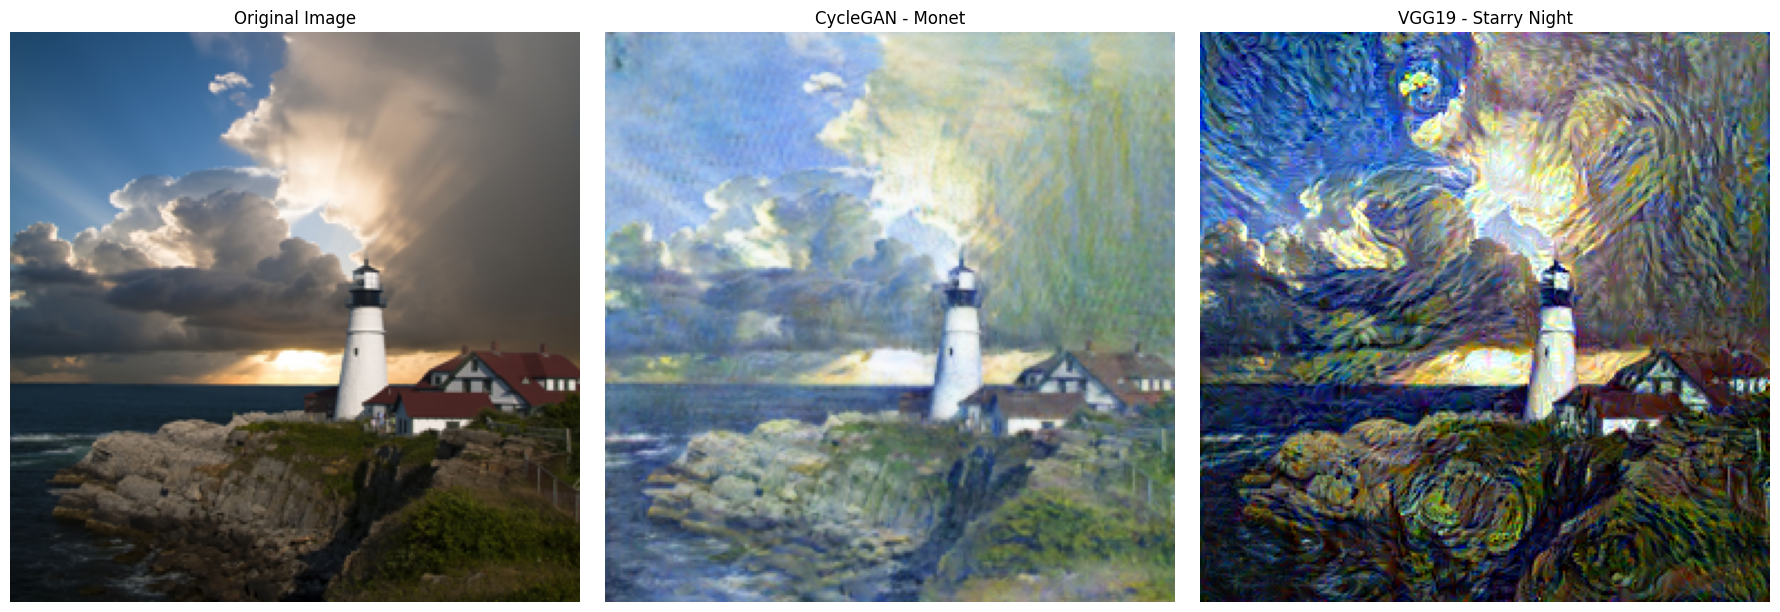

In [52]:
# ============================================
# SHOW 3 IMAGES SIDE BY SIDE
# ============================================

plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)
plt.imshow(content_image)
plt.title("Original Image")
plt.axis("off")


# CycleGAN
plt.subplot(1, 3, 2)

# CHANGE THIS VARIABLE if your CycleGAN
# output has a different name
plt.imshow(cyclegan_output)

plt.title("CycleGAN - Monet")
plt.axis("off")


# Neural Style Transfer
plt.subplot(1, 3, 3)
plt.imshow(output)
plt.title("VGG19 - Starry Night")
plt.axis("off")


plt.tight_layout()
plt.show()